# Pista F1 - Cuándo y por qué fallan los PINN.

## 📌 Resumen del Notebook
Aunque las Redes Neuronales Informadas por la Física (PINNs) han demostrado gran éxito, investigaciones recientes (Krishnapriyan et al., 2021) han revelado que pueden fallar catastróficamente incluso en problemas unidimensionales aparentemente simples.

En este cuaderno exploramos los **Modos de Fracaso** de las PINNs utilizando la **Ecuación de Convección Pura en 1D**. Demostraremos empíricamente cómo las altas velocidades de convección deforman el paisaje de pérdida, provocando fallos de optimización. Finalmente, implementaremos y compararemos dos estrategias avanzadas de mitigación propuestas en la literatura: *Curriculum Learning* y *Time-Marching (Sequence-to-Sequence)*.

## 1. Planteamiento Matemático de la Convección 🧮
La ecuación de convección pura modela la propagación de una onda a lo largo del espacio con una velocidad constante $\beta$:

$$\frac{\partial u}{\partial t} + \beta \frac{\partial u}{\partial x} = 0, \quad x \in [0, 2\pi], \quad t \in [0, 1]$$

Sujeta a las siguientes condiciones:
* **Condición Inicial:** $u(0, x) = \sin(x)$
* **Condiciones de Frontera:** Periódicas, $u(t, 0) = u(t, 2\pi)$

La solución analítica exacta de este sistema es una onda viajera: $u_{exact}(t, x) = \sin(x - \beta t)$.

En el siguiente bloque de código, configuraremos el entorno determinista e inicializaremos la arquitectura base (MLP) que utilizaremos a lo largo de todos los experimentos.

Iniciando escaneo de Breakpoint en cpu...

---> Entrenando para beta = 1.0...
Beta =  1.0 terminado | MSE Error final: 2.3700e-05

---> Entrenando para beta = 2.7142857142857144...
Beta =  2.7 terminado | MSE Error final: 2.7677e-04

---> Entrenando para beta = 4.428571428571429...
Beta =  4.4 terminado | MSE Error final: 3.3327e-04

---> Entrenando para beta = 6.142857142857142...
Beta =  6.1 terminado | MSE Error final: 3.1363e-02

---> Entrenando para beta = 7.857142857142857...
Beta =  7.9 terminado | MSE Error final: 1.4509e-02

---> Entrenando para beta = 9.571428571428571...
Beta =  9.6 terminado | MSE Error final: 5.3103e-02

---> Entrenando para beta = 11.285714285714285...
Beta = 11.3 terminado | MSE Error final: 1.5442e-01

---> Entrenando para beta = 13.0...
Beta = 13.0 terminado | MSE Error final: 4.3144e-01

---> Entrenando para beta = 14.714285714285714...
Beta = 14.7 terminado | MSE Error final: 5.6251e-01

---> Entrenando para beta = 16.428571428571427...
Beta = 16.4 t

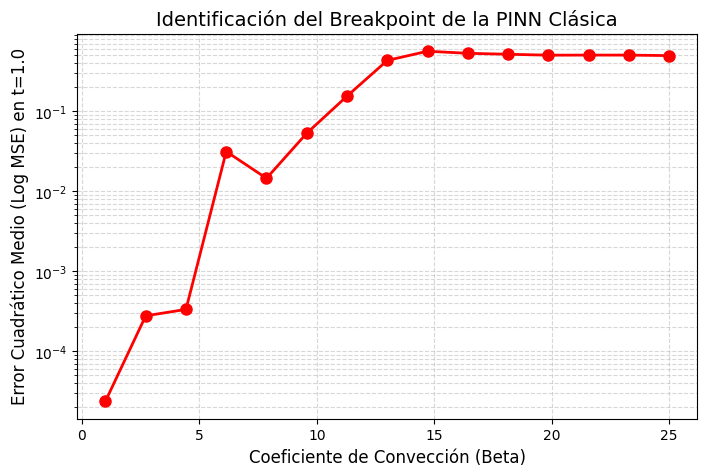

In [8]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 1. FUNCIÓN DE REPRODUCIBILIDAD
# ==========================================
def fijar_semilla(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# ==========================================
# 2. ARQUITECTURA DE LA PINN
# ==========================================
class ConvectionPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )
    def forward(self, t, x):
        return self.net(torch.cat([t, x], dim=1))

# ==========================================
# 3. EXPERIMENTO EN BUCLE PARA ENCONTRAR EL BREAKPOINT
# ==========================================
# Definimos los valores de beta que queremos testear
valores_beta = np.linspace(1, 25, 15)
errores_finales = []

epochs = 2000
N_pde = 2000
N_ic = 200

print(f"Iniciando escaneo de Breakpoint en {device}...")
t_experimento_inicio = time.time()

for beta in valores_beta:
    print(f"\n---> Entrenando para beta = {beta}...")

    # IMPORTANTE: Forzamos la misma semilla al inicio de cada beta
    fijar_semilla(42)

    model = ConvectionPINN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Generación de puntos (fijos por semilla para cada beta)
    t_pde = torch.rand(N_pde, 1, device=device).requires_grad_(True)
    x_pde = (torch.rand(N_pde, 1, device=device) * 2 * np.pi).requires_grad_(True)

    t_ic = torch.zeros(N_ic, 1, device=device)
    x_ic = (torch.rand(N_ic, 1, device=device) * 2 * np.pi)
    u_ic_target = torch.sin(x_ic)

    t_bc = torch.rand(200, 1, device=device)
    x_bc_0 = torch.zeros(200, 1, device=device)
    x_bc_2pi = torch.full((200, 1), 2 * np.pi, device=device)

    # Bucle de entrenamiento para el beta actual
    for epoch in range(epochs):
        optimizer.zero_grad()

        # Pérdida PDE
        u = model(t_pde, x_pde)
        u_t = torch.autograd.grad(u, t_pde, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_x = torch.autograd.grad(u, x_pde, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        loss_pde = torch.mean((u_t + beta * u_x) ** 2)

        # Pérdida IC
        u_ic_pred = model(t_ic, x_ic)
        loss_ic = torch.mean((u_ic_pred - u_ic_target) ** 2)

        # Pérdida BC (Periódica)
        loss_bc = torch.mean((model(t_bc, x_bc_0) - model(t_bc, x_bc_2pi)) ** 2)

        loss = loss_pde + 10.0 * loss_ic + loss_bc
        loss.backward()
        optimizer.step()

    # --- EVALUACIÓN DEL ERROR FINAL EN t = 1.0 ---
    model.eval()
    x_test = np.linspace(0, 2 * np.pi, 200)
    t_test = np.full_like(x_test, 1.0)

    u_exact = np.sin(x_test - beta * 1.0)

    t_tensor = torch.tensor(t_test, dtype=torch.float32, device=device).unsqueeze(1)
    x_tensor = torch.tensor(x_test, dtype=torch.float32, device=device).unsqueeze(1)

    with torch.no_grad():
        u_pred = model(t_tensor, x_tensor).cpu().numpy().flatten()

    # Calculamos el error MSE final para este beta específico
    mse_error = np.mean((u_pred - u_exact) ** 2)
    errores_finales.append(mse_error)
    print(f"Beta = {beta:4.1f} terminado | MSE Error final: {mse_error:.4e}")

print(f"\nExperimento completo en {time.time() - t_experimento_inicio:.2f} segundos.")

# ==========================================
# 4. GRAFICAR EL BREAKPOINT
# ==========================================
plt.figure(figsize=(8, 5))
plt.plot(valores_beta, errores_finales, 'r-o', linewidth=2, markersize=8)
plt.yscale('log') # Usamos escala logarítmica para ver la magnitud del salto
plt.xlabel('Coeficiente de Convección (Beta)', fontsize=12)
plt.ylabel('Error Cuadrático Medio (Log MSE) en t=1.0', fontsize=12)
plt.title('Identificación del Breakpoint de la PINN Clásica', fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.savefig('Breakpoint_Conveccion.png', bbox_inches='tight')
plt.show()

## 2. Diagnóstico del Fracaso: ¿Expresividad u Optimización? 🔬
El análisis del "Breakpoint" anterior demostró que la PINN colapsa abruptamente a medida que $\beta$ aumenta, rindiéndose ante la solución trivial $u=0$.

Para diagnosticar la raíz de este colapso, diseñamos un experimento de control. Entrenaremos **dos redes neuronales idénticas** (con los mismos pesos iniciales exactos) bajo alta convección ($\beta=15$):
1. **PINN Clásica:** Entrenada minimizando el residuo de la EDP (Física).
2. **Red Supervisada:** Entrenada con datos de la solución analítica (Datos).

Si la red supervisada logra aprender la onda, demostraremos que la arquitectura posee la **expresividad matemática** necesaria, y que el fracaso de la PINN es estrictamente un **problema de optimización** (un paisaje de pérdida mal condicionado por los operadores diferenciales).

Iniciando experimento comparativo con beta = 15.0 en cpu...

[1/2] Entrenando PINN (Guiada por la Física)...
[2/2] Entrenando Red Supervisada (Guiada por Datos de la solución)...

¡Entrenamiento completo! Evaluando resultados...

MSE Final PINN: 5.0655e-01
MSE Final Supervisado: 8.2223e-02


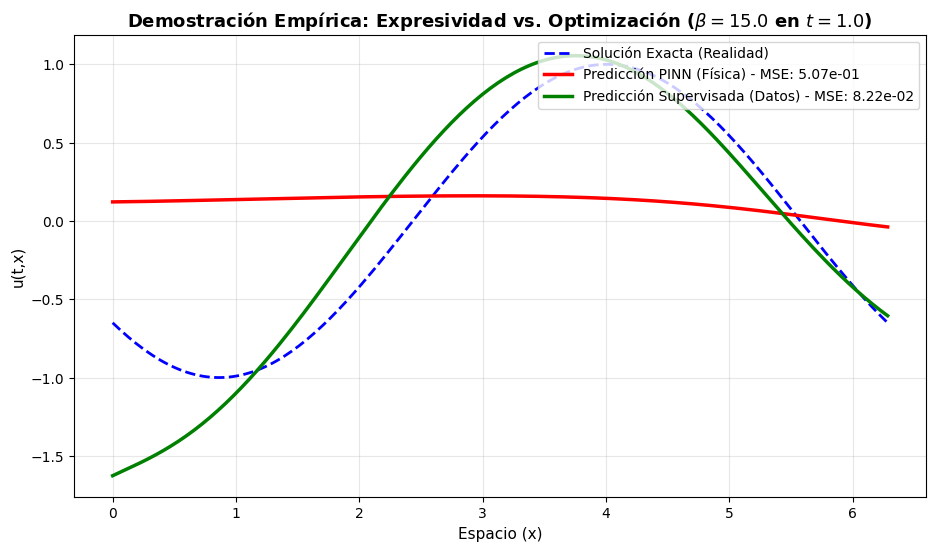

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 1. FUNCIÓN DE REPRODUCIBILIDAD
# ==========================================
def fijar_semilla(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# ==========================================
# 2. ARQUITECTURA DE LA RED NEURONAL
# ==========================================
# Ambas redes serán idénticas: 2 entradas (t, x), 3 capas de 64, 1 salida
class ConvectionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )
    def forward(self, t, x):
        return self.net(torch.cat([t, x], dim=1))

# Parámetros globales
beta = 15.0
epochs = 4000
N_puntos = 2000

print(f"Iniciando experimento comparativo con beta = {beta} en {device}...")

# ==========================================
# 3. ENTRENAMIENTO 1: PINN CLÁSICA (Física)
# ==========================================
fijar_semilla(42) # Inicialización idéntica
model_pinn = ConvectionNet().to(device)
optimizer_pinn = torch.optim.Adam(model_pinn.parameters(), lr=1e-3)

# Puntos para la PINN
t_pde = torch.rand(N_puntos, 1, device=device).requires_grad_(True)
x_pde = (torch.rand(N_puntos, 1, device=device) * 2 * np.pi).requires_grad_(True)
t_ic = torch.zeros(200, 1, device=device)
x_ic = (torch.rand(200, 1, device=device) * 2 * np.pi)
u_ic_target = torch.sin(x_ic)
t_bc = torch.rand(200, 1, device=device)
x_bc_0 = torch.zeros(200, 1, device=device)
x_bc_2pi = torch.full((200, 1), 2 * np.pi, device=device)

print("\n[1/2] Entrenando PINN (Guiada por la Física)...")
for epoch in range(epochs):
    optimizer_pinn.zero_grad()

    # Pérdida PDE
    u = model_pinn(t_pde, x_pde)
    u_t = torch.autograd.grad(u, t_pde, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x_pde, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    loss_pde = torch.mean((u_t + beta * u_x) ** 2)

    # Pérdida Condición Inicial y Frontera
    u_ic_pred = model_pinn(t_ic, x_ic)
    loss_ic = torch.mean((u_ic_pred - u_ic_target) ** 2)
    loss_bc = torch.mean((model_pinn(t_bc, x_bc_0) - model_pinn(t_bc, x_bc_2pi)) ** 2)

    loss_total = loss_pde + 10.0 * loss_ic + loss_bc
    loss_total.backward()
    optimizer_pinn.step()

# ==========================================
# 4. ENTRENAMIENTO 2: APRENDIZAJE SUPERVISADO (Datos)
# ==========================================
fijar_semilla(42) # Mismos pesos iniciales exactos que la PINN
model_supervised = ConvectionNet().to(device)
optimizer_sup = torch.optim.Adam(model_supervised.parameters(), lr=1e-3)

# Generamos datos exactos usando la solución analítica: u = sin(x - beta*t)
t_sup = torch.rand(N_puntos, 1, device=device)
x_sup = torch.rand(N_puntos, 1, device=device) * 2 * np.pi
u_sup_target = torch.sin(x_sup - beta * t_sup)

print("[2/2] Entrenando Red Supervisada (Guiada por Datos de la solución)...")
for epoch in range(epochs):
    optimizer_sup.zero_grad()

    # Pérdida supervisada clásica (MSE directo contra la solución exacta)
    u_pred = model_supervised(t_sup, x_sup)
    loss_sup = torch.mean((u_pred - u_sup_target) ** 2)

    loss_sup.backward()
    optimizer_sup.step()

print("\n¡Entrenamiento completo! Evaluando resultados...")

# ==========================================
# 5. EVALUACIÓN Y GRÁFICA COMPARATIVA en t = 1.0
# ==========================================
model_pinn.eval()
model_supervised.eval()

x_test = np.linspace(0, 2 * np.pi, 200)
t_test = np.full_like(x_test, 1.0)
u_exact = np.sin(x_test - beta * 1.0)

# Pasar a tensores para evaluar
t_tensor = torch.tensor(t_test, dtype=torch.float32, device=device).unsqueeze(1)
x_tensor = torch.tensor(x_test, dtype=torch.float32, device=device).unsqueeze(1)

with torch.no_grad():
    u_pred_pinn = model_pinn(t_tensor, x_tensor).cpu().numpy().flatten()
    u_pred_sup = model_supervised(t_tensor, x_tensor).cpu().numpy().flatten()

# Calcular errores MSE finales en t=1.0
mse_pinn = np.mean((u_pred_pinn - u_exact) ** 2)
mse_sup = np.mean((u_pred_sup - u_exact) ** 2)

print(f"\nMSE Final PINN: {mse_pinn:.4e}")
print(f"MSE Final Supervisado: {mse_sup:.4e}")

# Graficar
plt.figure(figsize=(11, 6))
plt.plot(x_test, u_exact, 'b--', linewidth=2, label='Solución Exacta (Realidad)')
plt.plot(x_test, u_pred_pinn, 'r-', linewidth=2.5, label=f'Predicción PINN (Física) - MSE: {mse_pinn:.2e}')
plt.plot(x_test, u_pred_sup, 'g-', linewidth=2.5, label=f'Predicción Supervisada (Datos) - MSE: {mse_sup:.2e}')

plt.title(f'Demostración Empírica: Expresividad vs. Optimización ($\\beta = {beta}$ en $t=1.0$)', fontsize=13, fontweight='bold')
plt.xlabel('Espacio (x)', fontsize=11)
plt.ylabel('u(t,x)', fontsize=11)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.savefig('Prueba_Expresividad_vs_Optimizacion.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Estrategia de Mitigación 1: Curriculum Learning 📈
Confirmado el problema de optimización, intentamos subsanarlo guiando al optimizador. En lugar de inicializar el entrenamiento en un régimen de alta rigidez, utilizaremos **Aprendizaje por Currículo (Continuación Paramétrica)**.

Entrenaremos la red secuencialmente, comenzando con una velocidad baja ($\beta=1$) y transfiriendo los pesos entrenados como punto de partida para la siguiente etapa ($\beta=5, 10, 15...$ hasta $30$). El objetivo es "surfear" la deformación del paisaje de pérdida manteniendo los pesos cerca del mínimo global.

Iniciando Curriculum Learning en cpu...
--- Etapa 1/7: Entrenando con beta = 1.0 ---
--- Etapa 2/7: Entrenando con beta = 5.0 ---
--- Etapa 3/7: Entrenando con beta = 10.0 ---
--- Etapa 4/7: Entrenando con beta = 15.0 ---
--- Etapa 5/7: Entrenando con beta = 20.0 ---
--- Etapa 6/7: Entrenando con beta = 25.0 ---
--- Etapa 7/7: Entrenando con beta = 30.0 ---

¡Entrenamiento completo en 223.10 segundos!
MSE Final con Curriculum (Beta=30.0): 5.2094e-01


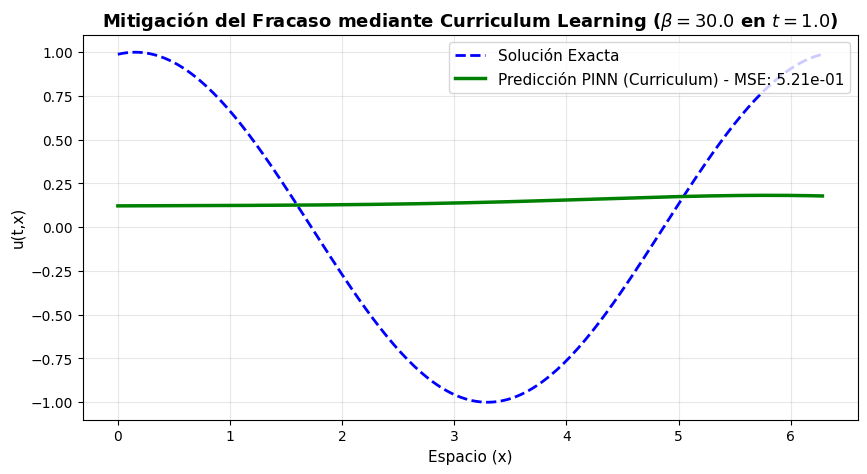

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def fijar_semilla(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

class ConvectionPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )
    def forward(self, t, x):
        return self.net(torch.cat([t, x], dim=1))

print(f"Iniciando Curriculum Learning en {device}...")

# ==========================================
# 1. INICIALIZACIÓN ÚNICA (El núcleo del Curriculum)
# ==========================================
fijar_semilla(42)
model_curriculum = ConvectionPINN().to(device)
optimizer = torch.optim.Adam(model_curriculum.parameters(), lr=1e-3)

# ==========================================
# 2. DEFINIR EL CURRÍCULO (De fácil a difícil)
# ==========================================
etapas_beta = [1.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0]
epochs_por_etapa = 1500

N_puntos = 2000

# Puntos fijos de entrenamiento
t_pde = torch.rand(N_puntos, 1, device=device).requires_grad_(True)
x_pde = (torch.rand(N_puntos, 1, device=device) * 2 * np.pi).requires_grad_(True)
t_ic = torch.zeros(200, 1, device=device)
x_ic = (torch.rand(200, 1, device=device) * 2 * np.pi)
u_ic_target = torch.sin(x_ic)
t_bc = torch.rand(200, 1, device=device)
x_bc_0 = torch.zeros(200, 1, device=device)
x_bc_2pi = torch.full((200, 1), 2 * np.pi, device=device)

# ==========================================
# 3. ENTRENAMIENTO SECUENCIAL
# ==========================================
t_start = time.time()

for etapa, beta_actual in enumerate(etapas_beta):
    print(f"--- Etapa {etapa+1}/{len(etapas_beta)}: Entrenando con beta = {beta_actual} ---")

    # IMPORTANTE: No reiniciamos el modelo aquí.
    # Usamos los pesos de la etapa anterior como punto de partida.

    for epoch in range(epochs_por_etapa):
        optimizer.zero_grad()

        # Pérdida PDE (usando el beta de esta etapa)
        u = model_curriculum(t_pde, x_pde)
        u_t = torch.autograd.grad(u, t_pde, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_x = torch.autograd.grad(u, x_pde, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        loss_pde = torch.mean((u_t + beta_actual * u_x) ** 2)

        # Pérdidas IC y BC
        u_ic_pred = model_curriculum(t_ic, x_ic)
        loss_ic = torch.mean((u_ic_pred - u_ic_target) ** 2)
        loss_bc = torch.mean((model_curriculum(t_bc, x_bc_0) - model_curriculum(t_bc, x_bc_2pi)) ** 2)

        loss = loss_pde + 10.0 * loss_ic + loss_bc
        loss.backward()
        optimizer.step()

print(f"\n¡Entrenamiento completo en {time.time() - t_start:.2f} segundos!")

# ==========================================
# 4. EVALUACIÓN FINAL (En el nivel más difícil: beta = 30)
# ==========================================
beta_final = etapas_beta[-1]
model_curriculum.eval()

x_test = np.linspace(0, 2 * np.pi, 200)
t_test = np.full_like(x_test, 1.0)
u_exact = np.sin(x_test - beta_final * 1.0)

t_tensor = torch.tensor(t_test, dtype=torch.float32, device=device).unsqueeze(1)
x_tensor = torch.tensor(x_test, dtype=torch.float32, device=device).unsqueeze(1)

with torch.no_grad():
    u_pred_curr = model_curriculum(t_tensor, x_tensor).cpu().numpy().flatten()

mse_final = np.mean((u_pred_curr - u_exact) ** 2)
print(f"MSE Final con Curriculum (Beta={beta_final}): {mse_final:.4e}")

# ==========================================
# 5. GRÁFICA DE ÉXITO
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(x_test, u_exact, 'b--', linewidth=2, label='Solución Exacta')
plt.plot(x_test, u_pred_curr, 'g-', linewidth=2.5, label=f'Predicción PINN (Curriculum) - MSE: {mse_final:.2e}')

plt.title(f'Mitigación del Fracaso mediante Curriculum Learning ($\\beta = {beta_final}$ en $t=1.0$)', fontsize=13, fontweight='bold')
plt.xlabel('Espacio (x)', fontsize=11)
plt.ylabel('u(t,x)', fontsize=11)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig('Exito_Curriculum_Conveccion.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Estrategia de Mitigación 2: Time-Marching (Seq2Seq) ⏱️
Como observamos, el Curriculum Learning no es suficiente para altas velocidades en tiempos prolongados, ya que la onda da demasiadas "vueltas" al dominio espacial, acumulando error.

Para solucionar esto definitivamente, implementamos el enfoque **Sequence-to-Sequence**. Imitando a los métodos numéricos tradicionales, dividiremos el dominio temporal completo ($T=1.0$) en 10 ventanas consecutivas de $\Delta t = 0.1$. La red se entrenará en ventanas cortas (donde el paisaje de pérdida es convexo) y utilizará su predicción final como condición inicial para la siguiente ventana.

Iniciando Time-Marching (Sequence-to-Sequence) en cpu...
--- Marchando ventana 1/10: t = [0.0, 0.1] ---
--- Marchando ventana 2/10: t = [0.1, 0.2] ---
--- Marchando ventana 3/10: t = [0.2, 0.3] ---
--- Marchando ventana 4/10: t = [0.3, 0.4] ---
--- Marchando ventana 5/10: t = [0.4, 0.5] ---
--- Marchando ventana 6/10: t = [0.5, 0.6] ---
--- Marchando ventana 7/10: t = [0.6, 0.7] ---
--- Marchando ventana 8/10: t = [0.7, 0.8] ---
--- Marchando ventana 9/10: t = [0.8, 0.9] ---
--- Marchando ventana 10/10: t = [0.9, 1.0] ---

¡Entrenamiento completo en 271.36 segundos!
MSE Final con Time-Marching (Beta=30.0): 3.6660e-02


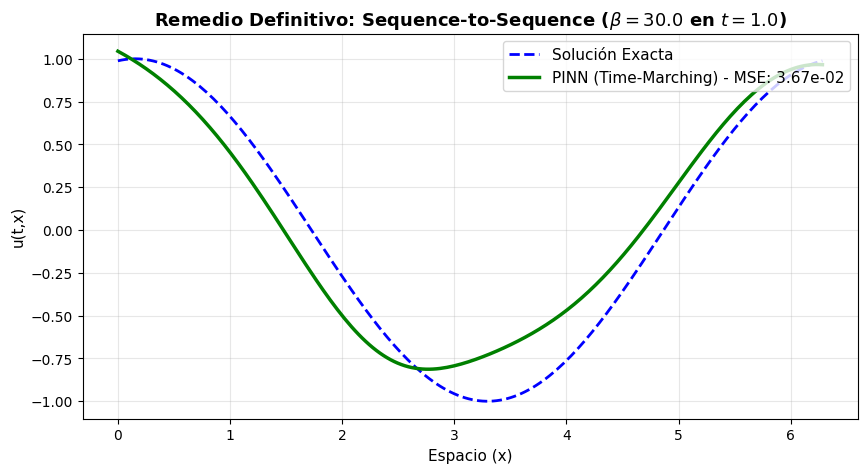

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def fijar_semilla(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

class ConvectionPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )
    def forward(self, t, x):
        return self.net(torch.cat([t, x], dim=1))

print(f"Iniciando Time-Marching (Sequence-to-Sequence) en {device}...")

# ==========================================
# 1. CONFIGURACIÓN DEL TIME-MARCHING
# ==========================================
beta = 30.0
pasos_tiempo = 10
dt = 1.0 / pasos_tiempo
epochs_por_paso = 2000

fijar_semilla(42)
model_time = ConvectionPINN().to(device)
optimizer = torch.optim.Adam(model_time.parameters(), lr=1e-3)

# Puntos fijos de frontera y espacio
N_pde = 1000
N_ic = 300

x_ic = (torch.rand(N_ic, 1, device=device) * 2 * np.pi)
# Condición Inicial real en t=0
u_ic_target = torch.sin(x_ic)

t_bc = torch.rand(200, 1, device=device) # Se escalará en cada paso
x_bc_0 = torch.zeros(200, 1, device=device)
x_bc_2pi = torch.full((200, 1), 2 * np.pi, device=device)

# ==========================================
# 2. BUCLE DE MARCHA EN EL TIEMPO
# ==========================================
t_start_train = time.time()

for paso in range(pasos_tiempo):
    t_inicio_ventana = paso * dt
    t_fin_ventana = (paso + 1) * dt

    print(f"--- Marchando ventana {paso+1}/{pasos_tiempo}: t = [{t_inicio_ventana:.1f}, {t_fin_ventana:.1f}] ---")

    # Preparar el tiempo inicial para esta ventana (para la Loss de IC)
    t_ic_ventana = torch.full((N_ic, 1), t_inicio_ventana, device=device)

    for epoch in range(epochs_por_paso):
        optimizer.zero_grad()

        # Generar puntos PDE aleatorios SOLO dentro de la ventana de tiempo actual
        t_pde = (torch.rand(N_pde, 1, device=device) * dt + t_inicio_ventana).requires_grad_(True)
        x_pde = (torch.rand(N_pde, 1, device=device) * 2 * np.pi).requires_grad_(True)

        u = model_time(t_pde, x_pde)
        u_t = torch.autograd.grad(u, t_pde, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_x = torch.autograd.grad(u, x_pde, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        loss_pde = torch.mean((u_t + beta * u_x) ** 2)

        # Pérdida de Condición Inicial (que es la final de la ventana anterior)
        u_ic_pred = model_time(t_ic_ventana, x_ic)
        loss_ic = torch.mean((u_ic_pred - u_ic_target) ** 2)

        # Pérdida BC Periódica dentro de la ventana actual
        t_bc_ventana = torch.rand(200, 1, device=device) * dt + t_inicio_ventana
        loss_bc = torch.mean((model_time(t_bc_ventana, x_bc_0) - model_time(t_bc_ventana, x_bc_2pi)) ** 2)

        loss = loss_pde + 10.0 * loss_ic + loss_bc
        loss.backward()
        optimizer.step()

    # AL FINALIZAR LA VENTANA: Predecimos el estado al final del tiempo
    # y lo "desconectamos" del gradiente (.detach()) para usarlo como la IC de la próxima ventana.
    with torch.no_grad():
        t_next_ic = torch.full((N_ic, 1), t_fin_ventana, device=device)
        u_ic_target = model_time(t_next_ic, x_ic).detach()

print(f"\n¡Entrenamiento completo en {time.time() - t_start_train:.2f} segundos!")

# ==========================================
# 3. EVALUACIÓN FINAL EN t=1.0
# ==========================================
model_time.eval()
x_test = np.linspace(0, 2 * np.pi, 200)
t_test = np.full_like(x_test, 1.0)
u_exact = np.sin(x_test - beta * 1.0)

t_tensor = torch.tensor(t_test, dtype=torch.float32, device=device).unsqueeze(1)
x_tensor = torch.tensor(x_test, dtype=torch.float32, device=device).unsqueeze(1)

with torch.no_grad():
    u_pred = model_time(t_tensor, x_tensor).cpu().numpy().flatten()

mse_final = np.mean((u_pred - u_exact) ** 2)
print(f"MSE Final con Time-Marching (Beta={beta}): {mse_final:.4e}")

# ==========================================
# 4. GRÁFICA DEL ÉXITO DEFINITIVO
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(x_test, u_exact, 'b--', linewidth=2, label='Solución Exacta')
plt.plot(x_test, u_pred, 'g-', linewidth=2.5, label=f'PINN (Time-Marching) - MSE: {mse_final:.2e}')

plt.title(f'Remedio Definitivo: Sequence-to-Sequence ($\\beta = {beta}$ en $t=1.0$)', fontsize=13, fontweight='bold')
plt.xlabel('Espacio (x)', fontsize=11)
plt.ylabel('u(t,x)', fontsize=11)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig('Exito_TimeMarching_Conveccion.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 💡 Conclusiones de la Pista F

Este exhaustivo análisis empírico nos permite concluir lo siguiente sobre el estado del arte de las PINNs:

1. **El peligro de la rigidez:** Las PINNs *vanilla* (clásicas) son inherentemente vulnerables a ecuaciones con dinámicas rápidas o alta convección. La penalización suave (*soft-constraint*) de la EDP vuelve al Hessiano de la pérdida altamente asimétrico, empujando al optimizador hacia mínimos locales triviales ($u=0$).
2. **Capacidad vs. Convergencia:** El fracaso no se debe a que la red neuronal sea "pequeña" o carezca de expresividad espacial, sino a que los algoritmos basados en gradiente (Adam) quedan ciegos en paisajes mal condicionados.
3. **El Remedio Temporal:** Aunque el *Curriculum Learning* ayuda a pre-acondicionar los pesos, la partición del dominio temporal (*Time-Marching*) es el remedio definitivo para preservar la causalidad física. Al acortar el horizonte de predicción, restauramos la convexidad local del problema, permitiendo a la PINN resolver escenarios de extrema dificultad de manera estable.